<p><font size="6" color='grey'> <b>
KI-Agenten. Verstehen. Anwenden. Gestalten.
</b></font> </br></p>



<p><font size="5" color='grey'> <b>
MCP Local
</b></font> </br></p>

---

In [ ]:
#@title 🛠️ Umgebung einrichten{ display-mode: "form" }
!uv pip install --system -q git+https://github.com/ralf-42/Agenten.git#subdirectory=04_modul
!uv pip install --system -q fastmcp langchain-mcp-adapters

import os
os.environ["LANGSMITH_TRACING"]  = "true"
os.environ["LANGSMITH_PROJECT"]  = "M30-MCP-Integration"
os.environ["LANGSMITH_ENDPOINT"] = "https://eu.api.smith.langchain.com"

from genai_lib.utilities import (
    check_environment,
    get_ipinfo,
    setup_api_keys,
    mprint,
    install_packages,
    mermaid,
    get_model_profile,
    extract_thinking,
    load_prompt,
    show_trace
)

setup_api_keys(['OPENAI_API_KEY', 'LANGSMITH_API_KEY'], create_globals=False)
print()
check_environment()
print()
get_ipinfo()

# Modell-Konfiguration — Rollen als Konstanten
from genai_lib.model_config import BASELINE, ROUTER, JUDGE, PLANNER, WORKER, WORKER_PREMIUM, CODING, EMBEDDINGS

✓ OPENAI_API_KEY erfolgreich gesetzt
✓ LANGSMITH_API_KEY erfolgreich gesetzt

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

Installierte LangChain- und LangGraph-Bibliotheken:
langchain                                1.2.12
langchain-chroma                         1.1.0
langchain-classic                        1.0.3
langchain-community                      0.4.1
langchain-core                           1.2.19
langchain-mcp-adapters                   0.2.2
langchain-ollama                         1.0.1
langchain-openai                         1.1.11
langchain-text-splitters                 1.1.1
langgraph                                1.1.2
langgraph-checkpoint                     4.0.1
langgraph-prebuilt                       1.0.8
langgraph-sdk                            0.3.11

IP-Adresse: 34.75.109.87
Hostname: 87.109.75.34.bc.googleusercontent.com
Stadt: North Charleston
Region: South Carolina
Land: US
Koordinaten: 32.8546,-79.9748
Provider: AS396982 Google L

# 1 | Übersicht
---


<p><font color='black' size="5">
@tool vs. MCP — wann welches Muster?
</font></p>



Agenten können Tools auf zwei grundlegend verschiedene Weisen nutzen:

| Kriterium | `@tool` (lokal) | MCP (remote) |
|-----------|----------------|-------------|
| **Laufzeit** | Im Jupyter-Kernel | Separater Prozess / Server |
| **Wiederverwendung** | Nur im aktuellen Notebook | Jede App, jedes LLM |
| **Sprache** | Nur Python | Python, Node.js, beliebig |
| **Skalierung** | Einfache Prototypen | Production-Services |
| **Sicherheit** | Direkter Code-Zugriff | Isolierter Prozess |
| **Protokoll** | LangChain intern | JSON-RPC 2.0 über HTTP |

**Faustregel:**

`@tool` für schnelle Prototypen und Kurs-Demos — MCP wenn Tools wiederverwendbar, sprachunabhängig oder produktionsreif sein sollen.


# 2 | Model Context Protocol (MCP)
---

<p><font color='black' size="5">Was ist MCP?</font></p>

Ein Protokoll ist ein Regelwerk, das bestimmt, wie zwei Systeme miteinander kommunizieren. Protokolle regeln die Datenübertragung in Computernetzwerken, bei der Internetkommunikation und zwischen Softwaresystemen.

**Zum Beispiel:**

- **HTTP** (Hypertext Transfer Protocol): Ermöglicht Websites die Kommunikation mit Browsern.
- **TCP/IP**: Definiert, wie Datenpakete im Internet geroutet werden.
- **JSON-RPC**: Ein Protokoll, das den Datenaustausch im JSON-Format ermöglicht.

Das **Model Context Protocol (MCP)** ist ein offenes Protokoll, das es großen Sprachmodellen (LLMs) ermöglicht, sich auf standardisierte Weise in externe Datenquellen und Tools zu integrieren. Dieses von Anthropic entwickelte Protokoll macht es KI-Modellen leicht, nahtlos mit einer Vielzahl von Tools und Datenquellen zusammenzuarbeiten — **ohne dass für jede Quelle spezifische API-Integrationen erforderlich sind**.





<p><font color='black' size="5">Warum wurde MCP entwickelt?</font></p>

Die Notwendigkeit von MCP ergibt sich aus den Ineffizienzen aktueller KI-API-Interaktionen. Derzeit ist der Aufbau von KI-Agenten, die Daten aus verschiedenen Quellen abrufen, **fragmentiert, repetitiv und schwer zu skalieren**. Jedes Tool spricht seine eigene Sprache und erfordert individuelle Integrationen. MCP reduziert diese Komplexität und minimiert den Entwicklungsaufwand.

```
Agent  →  MCP Client  →  MCP Server  →  Externe Ressource (DB, API, Filesystem)
       ←              ←              ←  Ergebnis
```

> Einmal als MCP-Server implementiert, funktioniert ein Tool mit **jedem kompatiblen LLM-Client** — Claude, GPT, LangGraph, u.a.

**Wichtige Ressourcen:**
- [Anthropic MCP](https://www.anthropic.com/news/model-context-protocol) — Offizielle Ankündigung und Spezifikation
- [MCP Server Gallery](https://github.com/modelcontextprotocol/servers) — Verfügbare Open-Source-Server

<p><font color='black' size="5">
Vier Kernkomponenten:
</font></p>


| Komponente | Aufgabe | Beispiele |
|------------|---------|-----------|
| **MCP Host** | Die Anwendung, die den Client enthält und den Agenten ausführt | Chat-App, IDE-Assistent, Jupyter Notebook |
| **MCP Client** | Protokoll-Komponente innerhalb des Hosts — verbindet sich zu Servern, lädt Tool-Definitionen | `MultiServerMCPClient` |
| **MCP Server** | Stellt Tools bereit, implementiert JSON-RPC 2.0 — sprachunabhängig | FastMCP (Python), Node.js, beliebig |
| **LLM / Agent** | Entscheidet welche Tools gebraucht werden, orchestriert die Aufrufe | LangGraph ReAct-Agent |

> Ein Host kann mehrere Clients enthalten, ein Client kann sich zu mehreren Servern verbinden.

<p><font color='black' size="5">
Transport-Optionen:
</font></p>


| Transport | Beschreibung | Einsatz |
|-----------|-------------|---------|
| `streamable_http` | HTTP POST mit JSON-RPC 2.0 | **Web-Services, Notebooks** ✅ |
| `stdio` | Standard Input/Output | Lokale Prozesse (Claude Desktop) |
| `sse` | Server-Sent Events | Echtzeit-Streaming vom Server |
| `websocket` | Bidirektionale Verbindung | Hochperformante Anwendungen |

> Dieses Modul verwendet `streamable_http` — ideal für Jupyter und Web-Deployments.

✏️ Vergleich der MCP Transport-Optionen

<details>



| Transport | Beschreibung | Funktionsweise | Primärer Use-Case |
| --- | --- | --- | --- |
| **`stdio`** | **Standard Input/Output** | Daten werden über die Konsole (`stdin`/`stdout`) ausgetauscht. | **Lokale Integration:** Wenn der LLM-Client (z.B. Claude Desktop) den Server direkt als Prozess startet. |
| **`streamable_http`** | **HTTP-basiert** | Nutzt Standard `HTTP POST` Anfragen für den Austausch von JSON-RPC Objekten. | **Web-Services:** Ideal für Cloud-Infrastrukturen und Notebook-Umgebungen (wie in diesem Beispiel). |
| **`sse`** | **Server-Sent Events** | Ein unidirektionaler Stream vom Server zum Client über eine offene HTTP-Verbindung. | **Streaming:** Wenn der Server Antworten in Echtzeit "pushen" muss, ohne auf neue Anfragen zu warten. |
| **`websocket`** | **WebSockets** | Eine dauerhafte, voll-bidirektionale Verbindung zwischen beiden Parteien. | **Hochperformante Apps:** Wenn minimale Latenz und ständiger Datenaustausch in beide Richtungen nötig sind. |

</details>


✏️ MCP-Infrastruktur: Von der Verbindung zum Befehl

<details>

   

1. Das Fundament: **HTTP (Transport)**
Bevor Daten fließen, wird eine Verbindung via HTTP (Hypertext Transfer Protocol) hergestellt.

    + Der Server als Web-Service: Erreichbar unter einer festen Adresse (URL).

    + Die Methode: Nutzt HTTP POST, um Datenpakete gezielt an den Server zu senden.

    + Vorteil: Funktioniert überall (Firewall-freundlich) und ist der Standard für moderne Software-Kommunikation.

2. Der Inhalt: **JSON-RPC 2.0 (Protokoll)**
Innerhalb des HTTP-Transports wird die "Sprache" JSON-RPC gesprochen. Sie strukturiert den eigentlichen Befehl.

    + Anfrage: Enthält die id (Zuordnung), die method (Tool-Name) und params (Eingabewerte).

    + Antwort: Liefert das result oder eine Fehlermeldung zurück an den Agenten.

    + Vorteil: Schlank und präzise – es wird nur das übertragen, was für den Funktionsaufruf nötig ist.

3. Kurzübersicht: Die Hierarchie        
    + Transport-Layer (HTTP): Der LKW, der das Paket von A nach B bringt.
    + Payload-Layer (JSON-RPC): Der Inhalt des Pakets (der eigentliche Arbeitsauftrag).

Fazit: Erst wenn der HTTP-Kanal steht, kann JSON-RPC die Tools des MCP-Servers steuern.


</details>

✏️ Model Context Protocol (MCP) – JSON-RPC Kommunikation

<details>

Das MCP nutzt **JSON-RPC 2.0 über HTTP**. In der Praxis bedeutet das:

1. Der **Client** sendet eine `HTTP POST`-Anfrage an den Server.
2. Der **Body** enthält ein JSON-Objekt nach der JSON-RPC 2.0 Spezifikation.
3. Der **Server** antwortet mit `HTTP 200 OK` und dem entsprechenden Ergebnis im Body.

---

**Beispiel: Tool-Aufruf (`add`)**

Stellen wir uns vor, ein LangChain Agent möchte das Tool `add` mit den Werten  und  aufrufen.

*1. Client an Server (Request)*

Der Client sendet eine Anfrage an `http://127.0.0.1:8000/mcp`:

```json
{
  "jsonrpc": "2.0",
  "method": "add",
  "params": {
    "a": 3,
    "b": 5
  },
  "id": "some-unique-request-id"
}

```

Erklärung der Felder:

* **`jsonrpc`**: Die Protokoll-Version (immer `"2.0"`).
* **`method`**: Der Name des aufzurufenden Tools (hier: `add`).
* **`params`**: Ein Objekt mit den Argumenten als Schlüssel-Wert-Paare (entspricht den Python-Parametern `a` und `b`).
* **`id`**: Eine eindeutige ID, um die Antwort später der richtigen Anfrage zuzuordnen.

---

*2. Server an Client (Response)*

Nach erfolgreicher Ausführung sendet der Server das Ergebnis zurück:

```json
{
  "jsonrpc": "2.0",
  "result": 8,
  "id": "some-unique-request-id"
}

```

* **`result`**: Der berechnete Rückgabewert (hier: ).
* **`id`**: Muss exakt mit der ID der Anfrage übereinstimmen.

---

Fehlerbehandlung:

Sollte während der Ausführung ein Fehler auftreten (z. B. eine Division durch Null), liefert der Server ein `error`-Objekt anstelle des `result`-Feldes:

```json
{
  "jsonrpc": "2.0",
  "error": {
    "code": -32000,
    "message": "ValueError: Division durch 0 ist nicht erlaubt"
  },
  "id": "some-unique-request-id"
}

```

---

> Dies ist die Datenstruktur, die über die `streamable_http`-Verbindung ausgetauscht wird. Tools wie der `langchain-mcp-adapters` Client und der `FastMCP` Server übernehmen die Serialisierung automatisch.

</details>

<p><font color='black' size="5">
Praktisches Beispiel: Was passiert?
</font></p>



Ein AI-Assistent hat die Aufgabe: **Berechne (3+5) ✕ 12**

**Ohne MCP:**
```
AI: "Das Ergebnis ist ungefähr 96."
```
→ AI rät oder rechnet im *Kopf* (fehleranfällig)

**Mit MCP:**
```
1. AI: "Ich brauche das add-Tool"
2. MCP Client → Server: add(3, 5)
3. Server → Client: 8
4. AI: "Ich brauche das multiply-Tool"
5. MCP Client → Server: multiply(8, 12)
6. Server → Client: 96
7. AI: "Das Ergebnis ist 96."
```
→ AI nutzt echte Tools (präzise, nachvollziehbar)

**Der Vorteil:**
- ✅ Präzise Ergebnisse (keine Halluzinationen)
- ✅ Erweiterbar (neue Tools einfach hinzufügen)
- ✅ Wiederverwendbar (gleicher Server für viele AIs)
- ✅ Nachvollziehbar (jeder Tool-Call ist dokumentiert)


<p><font color='black' size="5">
Lokaler vs. öffentlicher MCP-Server
</font></p>



MCP-Server können auf zwei grundlegend verschiedene Arten betrieben werden:

| Merkmal | Lokaler Server (dieses Modul)| HF Space Server |
|---------|---------------|--------------------------------|
| **Adresse** | `127.0.0.1:8001/mcp` | `https://ralf42-simple-mcp.hf.space/mcp` |
| **Erreichbarkeit** | Nur lokal im Jupyter-Kernel | Öffentlich, weltweit |
| **Lebensdauer** | Nur während der Notebook-Session | Permanent (schläft nach Inaktivität ein) |
| **Deployment** | `subprocess.Popen(...)` im Notebook | Einmalig auf HF Space deployen |
| **MCP-Protokoll** | ✅ identisch | ✅ identisch |
| **Transport** | `streamable_http` | `streamable_http` |

> **Das MCP-Protokoll ist in beiden Fällen identisch** — nur die Adresse ändert sich.
> `MultiServerMCPClient` verbindet sich genauso — nur mit einer anderen URL.

**Faustregel:**      
Lokaler Server für schnelle Prototypen und Kurs-Demos — HF Space wenn der Server dauerhaft und öffentlich zugänglich sein soll.

# 3 | Lokalen Server erstellen
---

✏️ Ports & localhost
<details>

Beim Aufruf einer URL wie `http://127.0.0.1:8000/1/mcp` läuft intern folgender Prozess ab:

Der Rechner kommuniziert mit sich selbst (über `127.0.0.1`) und leitet die Anfrage an ein **konkretes Programm** weiter – identifiziert über den **Port**.

Da mehrere Programme gleichzeitig Netzwerkverbindungen nutzen (z. B. Browser, Datenbank, API), benötigt jedes Programm einen eigenen „Eingang“.
Dieser Eingang wird als **Port** bezeichnet.

---

**Kurzdefinitionen**

**`127.0.0.1` (localhost)**    
→ Eigener Rechner (Loopback)   
→ Kommunikation bleibt vollständig lokal   

**Ports (0–65535)**    
→ Virtuelle Eingänge für Programme    
→ Ermöglichen parallele Netzwerkkommunikation    

---

**Komplett-Beispiel (MCP)**

```id="k2y7vd"
http://127.0.0.1:8000/1/mcp
        └──────┬──────┘
               │
     Adresse + Port = Zielprogramm
```

| Komponente  | Bedeutung                                 | Beispiel     |
| ----------- | ----------------------------------------- | ------------ |
| `127.0.0.1` | Lokaler Rechner (nicht extern erreichbar) | Dev-Server   |
| `:8000`     | Port → welches Programm hört dort?        | FastAPI/MCP  |
| `/1/mcp`    | Route innerhalb der Anwendung             | API-Endpunkt |

---

**Wichtige Präzisierung**

* Ein **Port ist kein Programm**
* Ein Programm **bindet sich an einen Port**
* Beispiel:    
  → FastAPI auf Port 8000   
  → anderes Tool z. B. auf Port 3000    

---

**Mentales Modell**

* IP = **Hausadresse**
* Port = **Wohnung**
* Pfad = **Person in der Wohnung**

---

**Merksatz**

> `127.0.0.1` = Kommunikation mit dem eigenen Rechner     
> `:8000` = Weiterleitung an die Anwendung, die dort lauscht   

---

**Kritischer Zusatz**

„Lokal“ bedeutet lediglich: **nicht von außen erreichbar**      
→ keine Garantie für Sicherheit (z. B. bei unsicheren APIs)


In [ ]:
%%writefile math_mcp_server.py
from fastmcp import FastMCP

mcp = FastMCP('MathTools')

@mcp.tool()
def add(a: float, b: float) -> float:
    '''Addiert zwei Zahlen.'''
    return a + b

@mcp.tool()
def multiply(a: float, b: float) -> float:
    '''Multipliziert zwei Zahlen.'''
    return a * b

@mcp.tool()
def subtract(a: float, b: float) -> float:
    '''Subtrahiert b von a.'''
    return a - b

@mcp.tool()
def divide(a: float, b: float) -> float:
    '''Teilt a durch b.'''
    if b == 0:
        raise ValueError('Division durch 0 nicht erlaubt')
    return a / b

if __name__ == '__main__':
    mcp.run(transport='http', host='127.0.0.1', port=8001, path='/mcp')

Overwriting math_mcp_server.py


In [ ]:
# Server als subprocess starten
import subprocess, time, sys

mprint("### 🚀 Math-MCP-Server (Port 8001)\n---")

math_server_process = subprocess.Popen(
    [sys.executable, "math_mcp_server.py"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
print("⏳ Starte Server...")

import requests
for i in range(12):
    try:
        r = requests.post("http://127.0.0.1:8001/mcp",
                          json={"jsonrpc":"2.0","method":"tools/list","id":1}, timeout=2)
        if r.status_code in [200, 400, 406]:
            break
    except Exception:
        time.sleep(1)

mprint("\n✅ Math-MCP-Server läuft auf `http://127.0.0.1:8001/mcp`")
print(f"   PID: {math_server_process.pid} | Tools: add, multiply, subtract, divide")

### 🚀 Math-MCP-Server (Port 8001)
---

⏳ Starte Server...



✅ Math-MCP-Server läuft auf `http://127.0.0.1:8001/mcp`

   PID: 13342 | Tools: add, multiply, subtract, divide


In [ ]:
# Server Health-Check
import requests

try:
    r = requests.get("http://127.0.0.1:8001/mcp", timeout=3)
    # Status 400/405/406 mit JSON = Server läuft korrekt
    if r.status_code in [200, 400, 405, 406]:
        print(f"✅ Server ONLINE — HTTP {r.status_code} (erwartet)")
    else:
        print(f"⚠️ Unerwarteter Status: {r.status_code}")
except Exception as e:
    print(f"❌ Server nicht erreichbar: {e}")

✅ Server ONLINE — HTTP 406 (erwartet)


# 4 | MCP-Server für LangGraph-Agenten
---

Der `MultiServerMCPClient` aus `langchain-mcp-adapters` lädt die Tool-Definitionen vom Server und macht sie für LangGraph-Agenten verfügbar.

**Ablauf in zwei Phasen:**

```
Phase 1 — Handshake & Tool-Discovery:
  Client → Server: initialize
  Server → Client: Capabilities
  Client → Server: tools/list
  Server → Client: [add, multiply, subtract, divide]

Phase 2 — Tool-Ausführung (pro Agent-Schritt):
  Agent → Client: Tool-Call "add(3, 5)"
  Client → Server: HTTP POST JSON-RPC
  Server → Client: 8
  Agent bekommt: ToolMessage(content="8")
```

In [ ]:
#@markdown   <p><font size="4" color='green'>  sequenceDiagram: Handshake + Tool Discovery</font> </br></p>

diagram = '''
sequenceDiagram
    autonumber
    actor User
    participant Agent as LangGraph Agent
    participant Client as MCP Client
    participant Server as FastMCP Server

    Note over Agent,Server: Phase 1 — Handshake & Tool Discovery
    Client->>Server: HTTP POST (initialize)
    Server-->>Client: Capabilities & Version
    Client->>Server: HTTP POST (tools/list)
    Server-->>Client: [add, multiply, subtract, divide]

    Note over Agent,Server: Phase 2 — Agent-Query
    User->>Agent: "Berechne (3+5) × 12"
    Agent->>Client: Tool: add(3, 5)
    Client->>Server: HTTP POST JSON-RPC
    Server-->>Client: 8
    Client-->>Agent: ToolMessage("8")
    Agent->>Client: Tool: multiply(8, 12)
    Client->>Server: HTTP POST JSON-RPC
    Server-->>Client: 96
    Client-->>Agent: ToolMessage("96")
    Agent->>User: "Das Ergebnis ist 96"
'''
mermaid(diagram, width=750)

<p><font color='black' size="5">
MCP Client + Tools laden
</font></p>

In [ ]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client_math = MultiServerMCPClient({
    "math": {
        "transport": "streamable_http",
        "url": "http://127.0.0.1:8001/mcp"
    }
})

math_tools = await client_math.get_tools()

print(f"✅ {len(math_tools)} Tools geladen:")
for t in math_tools:
    print(f"   • {t.name}: {t.description}")

✅ 4 Tools geladen:
   • add: Addiert zwei Zahlen.
   • multiply: Multipliziert zwei Zahlen.
   • subtract: Subtrahiert b von a.
   • divide: Teilt a durch b.


<p><font color='black' size="5">
MCP Inspector
</font></p>



Der MCP-Inspector ist ein Browser-Tool zum Testen und Debuggen von MCP-Servern. Man startest ihn mit `npx` und verbindest ihn dann entweder mit einem lokalen Server-Command oder direkt mit einer Remote-URL; danach kann man Tools, Resources und Prompts prüfen.

In [ ]:
#@markdown   <p><font size="4" color='green'>  URL für MCP Inspector</font> </br></p>

# Tunnel für Math-Server (Port 8001)
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

import subprocess, time, re

tunnel = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:8001"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)

time.sleep(5)
public_url = None
for _ in range(30):
    line = tunnel.stderr.readline().decode()
    if "trycloudflare.com" in line:
        match = re.search(r'https://\S+\.trycloudflare\.com', line)
        if match:
            public_url = match.group()
            break

print(f"✅ Tunnel aktiv: {public_url}")
print(f"\nMCP Inspector:")
print(f"npx @modelcontextprotocol/inspector {public_url}/mcp --transport http")

✅ Tunnel aktiv: https://existing-mental-saturn-videos.trycloudflare.com

MCP Inspector:
npx @modelcontextprotocol/inspector https://existing-mental-saturn-videos.trycloudflare.com/mcp --transport http


<p><font color='black' size="5">
LangGraph ReAct-Agent mit MCP-Tools
</font></p>

In [ ]:
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain.agents import create_agent
from IPython.display import Image as IPImage, display

llm = init_chat_model(BASELINE, temperature=0.0)

MATH_AGENT_PROMPT = load_prompt(
    "https://github.com/ralf-42/Agenten/blob/main/05_prompt/m30_math_agent_prompt.md",
    mode="S",
)

math_agent = create_agent(
    model=llm,
    tools=math_tools,
    system_prompt=MATH_AGENT_PROMPT,
)

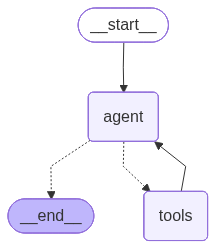

In [ ]:
display(IPImage(math_agent.get_graph(xray=True).draw_mermaid_png()))


<p><font color='black' size="5">
Demo: Einfache und komplexe Berechnungen
</font></p>

In [ ]:
queries = [
    "Berechne 127 × 8.",
    "Was ist (3 + 5) × 12?",
    "Berechne (100 - 20) / 4.",
]

for query in queries:
    result = await math_agent.ainvoke(
        {"messages": [HumanMessage(query)]},
        config={"run_name": "M30-MathAgent", "tags": ["m30", "math-agent"]},
    )
    mprint(f"**Query:** {query}\n\n**Antwort:** {result['messages'][-1].content}\n\n---")

**Query:** Berechne 127 × 8.

**Antwort:** Das Ergebnis von 127 × 8 ist 1016.

---

**Query:** Was ist (3 + 5) × 12?

**Antwort:** Das Ergebnis von (3 + 5) × 12 ist 96.

---

**Query:** Berechne (100 - 20) / 4.

**Antwort:** Das Ergebnis von \((100 - 20) / 4\) ist 20.

---

# 5 | Custom MCP-Tools entwickeln
---

Jede Python-Funktion kann mit `@mcp.tool()` zu einem MCP-Tool werden. Wichtig: **Typ-Annotationen** und **Docstrings** sind für das LLM essentiell — sie beschreiben, wann und wie das Tool eingesetzt werden soll.

```python
@mcp.tool()
def erstelle_notiz(id: str, inhalt: str) -> str:
    """Erstellt eine neue Notiz mit der angegebenen ID."""
    notizen[id] = inhalt
    return f"Notiz {id!r} gespeichert."
```

**Design-Regeln für MCP-Tools:**

| Regel | Begründung |
|-------|----------|
| Eindeutige, beschreibende Namen | LLM wählt Tool anhand des Namens |
| Präzise Docstrings (1 Satz) | Wird direkt an das LLM übergeben |
| Typ-Annotationen für alle Parameter | Erzeugt automatisch JSON-Schema |
| Atomare Operationen | Ein Tool = eine Aufgabe |
| Fehlerbehandlung im Tool | LLM erhält lesbares Feedback |

In [26]:
#@markdown   <p><font size="4" color='green'>  Notiz-Server Architektur</font> </br></p>

diagram = '''
%%{init: {'theme':'forest'}}%%
flowchart LR
    A["LangGraph Agent"]
    C["MCP Client"]
    S["Notiz-Server\nPort 8002"]
    DB[("In-Memory\nnotizen = {}")]

    A -->|Tool Call| C
    C -->|HTTP POST| S
    S -->|lesen/schreiben| DB
    S -->|Ergebnis| C
    C -->|ToolMessage| A

    subgraph tools ["Tools: NotizTools"]
        T1["erstelle_notiz(id, inhalt)"]
        T2["lese_notiz(id)"]
        T3["liste_notizen()"]
        T4["loesche_notiz(id)"]
    end
    S --- tools

    style A  fill:#2E7D32,color:#fff
    style C  fill:#1565C0,color:#fff
    style S  fill:#37474F,color:#fff
    style DB fill:#4A148C,color:#fff
'''
mermaid(diagram, width=1250)


<p><font color='black' size="5">
Notiz-Server erstellen und starten
</font></p>


In [27]:
%%writefile notiz_mcp_server.py
from fastmcp import FastMCP

mcp = FastMCP('NotizTools')
notizen = {}  # In-Memory Speicher

@mcp.tool()
def erstelle_notiz(id: str, inhalt: str) -> str:
    '''Erstellt oder überschreibt eine Notiz mit der angegebenen ID.'''
    notizen[id] = inhalt
    return f'Notiz {id!r} gespeichert ({len(inhalt)} Zeichen).'

@mcp.tool()
def lese_notiz(id: str) -> str:
    '''Liest den Inhalt einer Notiz anhand ihrer ID.'''
    return notizen.get(id, f'Notiz {id!r} nicht gefunden.')

@mcp.tool()
def liste_notizen() -> str:
    '''Listet alle gespeicherten Notiz-IDs und deren Anfang auf.'''
    if not notizen:
        return 'Keine Notizen vorhanden.'
    return '\n'.join(f'• {k}: {v[:40]}...' if len(v)>40 else f'• {k}: {v}' for k,v in notizen.items())

@mcp.tool()
def loesche_notiz(id: str) -> str:
    '''Löscht eine Notiz mit der angegebenen ID.'''
    if id in notizen:
        del notizen[id]
        return f'Notiz {id!r} gelöscht.'
    return f'Notiz {id!r} nicht gefunden.'

if __name__ == '__main__':
    mcp.run(transport='http', host='127.0.0.1', port=8002, path='/mcp')

Overwriting notiz_mcp_server.py


In [28]:
# Notiz-Server als subprocess starten
import subprocess, time, sys, requests

print("✅ notiz_mcp_server.py erstellt")

notiz_server_process = subprocess.Popen(
    [sys.executable, "notiz_mcp_server.py"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
print("⏳ Starte Notiz-Server auf Port 8002...")

for i in range(12):
    try:
        r = requests.post("http://127.0.0.1:8002/mcp",
                          json={"jsonrpc":"2.0","method":"tools/list","id":1}, timeout=2)
        if r.status_code in [200, 400, 406]: break
    except Exception:
        time.sleep(1)

mprint("\n✅ Notiz-Server läuft auf http://127.0.0.1:8002/mcp")
print(f"   PID: {notiz_server_process.pid} | Tools: erstelle, lese, liste, loesche")

✅ notiz_mcp_server.py erstellt
⏳ Starte Notiz-Server auf Port 8002...



✅ Notiz-Server läuft auf http://127.0.0.1:8002/mcp

   PID: 15695 | Tools: erstelle, lese, liste, loesche



<p><font color='black' size="5">
Agent mit Notiz-Tools
</font></p>

In [29]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_core.messages import HumanMessage

client_notiz = MultiServerMCPClient({
    "notiz": {
        "transport": "streamable_http",
        "url": "http://127.0.0.1:8002/mcp"
    }
})
notiz_tools = await client_notiz.get_tools()
print(f"✅ {len(notiz_tools)} Notiz-Tools geladen: {[t.name for t in notiz_tools]}")

NOTIZ_AGENT_PROMPT = load_prompt(
    "https://github.com/ralf-42/Agenten/blob/main/05_prompt/m30_notiz_agent_prompt.md",
    mode="S",
)

notiz_agent = create_agent(
    model=llm,
    tools=notiz_tools,
    system_prompt=NOTIZ_AGENT_PROMPT,
)

aufgaben = [
    "Erstelle eine Notiz 'einkauf' mit dem Inhalt: Milch, Brot, Eier, Käse.",
    "Erstelle eine Notiz 'meeting' mit dem Inhalt: Montag 10:00 Uhr, Thema MCP-Integration.",
    "Liste alle vorhandenen Notizen auf.",
    "Lese den Inhalt der Notiz 'einkauf'.",
    "Lösche die Notiz 'meeting' und bestätige die verbleibenden Notizen.",
]

for aufgabe in aufgaben:
    result = await notiz_agent.ainvoke(
        {"messages": [HumanMessage(aufgabe)]},
        config={"run_name": "M30-NotizAgent", "tags": ["m30", "notiz-agent"]},
    )
    mprint(f"**Aufgabe:** {aufgabe}\n\n**Antwort:** {result['messages'][-1].content}\n\n---")

✅ 4 Notiz-Tools geladen: ['erstelle_notiz', 'lese_notiz', 'liste_notizen', 'loesche_notiz']


**Aufgabe:** Erstelle eine Notiz 'einkauf' mit dem Inhalt: Milch, Brot, Eier, Käse.

**Antwort:** Die Notiz 'einkauf' wurde erfolgreich mit dem Inhalt: Milch, Brot, Eier, Käse gespeichert.

---

**Aufgabe:** Erstelle eine Notiz 'meeting' mit dem Inhalt: Montag 10:00 Uhr, Thema MCP-Integration.

**Antwort:** Die Notiz 'meeting' wurde erfolgreich erstellt.

---

**Aufgabe:** Liste alle vorhandenen Notizen auf.

**Antwort:** Hier sind die vorhandenen Notizen:

1. **einkauf**: Milch, Brot, Eier, Käse
2. **meeting**: Montag 10:00 Uhr, Thema MCP-Integration.

---

**Aufgabe:** Lese den Inhalt der Notiz 'einkauf'.

**Antwort:** Die Notiz 'einkauf' enthält: Milch, Brot, Eier, Käse.

---

**Aufgabe:** Lösche die Notiz 'meeting' und bestätige die verbleibenden Notizen.

**Antwort:** Die Notiz 'meeting' wurde gelöscht. Verbleibende Notiz: 

- **einkauf**: Milch, Brot, Eier, Käse.

---

<p><font color='black' size="5">
Resources & Prompts
</font></p>

MCP-Server bieten neben **Tools** zwei weitere Komponenten an:

| Komponente | Zweck | Decorator | Wer nutzt es |
|------------|-------|-----------|---------------|
| **Tools** | Funktionen die der Agent aktiv aufruft | `@mcp.tool()` | LangGraph-Agent (automatisch) |
| **Resources** | Statische oder dynamische Daten (read-only) | `@mcp.resource()` | Client liest direkt |
| **Prompts** | Wiederverwendbare Prompt-Templates | `@mcp.prompt()` | Client lädt bei Bedarf |

> **Wichtig:** LangGraph-Agenten nutzen aktuell nur Tools automatisch. Resources und Prompts werden manuell über den Client abgerufen.

In [30]:
#@markdown   <p><font size="4" color='green'>  Resources & Prompts Architektur</font> </br></p>

diagram = '''
%%{init: {'theme':'forest'}}%%
flowchart LR
    C["MCP Client"]
    S["InfoTools-Server<br/>Port 8003"]

    subgraph tools ["Tools"]
        T1["wetter(stadt)"]
    end
    subgraph resources ["Resources"]
        R1["info://staedte/liste"]
        R2["info://server/version"]
    end
    subgraph prompts ["Prompts"]
        P1["wetterbericht(stadt, einheit)"]
    end

    %% Kommunikation läuft über den Server
    C -->|JSON-RPC| S

    %% Der Server exponiert die Inhalte
    S --- T1
    S --- R1
    S --- R2
    S --- P1

    style C fill:#1565C0,color:#fff
    style S fill:#37474F,color:#fff
'''
mermaid(diagram, width=800)

<p><font color='black' size="5">
InfoTools-Server: Tools, Resources und Prompts
</font></p>

In [31]:
%%writefile info_mcp_server.py
from fastmcp import FastMCP

mcp = FastMCP('InfoTools')

# --- TOOLS ---
@mcp.tool()
def wetter(stadt: str) -> str:
    '''Gibt eine simulierte Wetterauskunft für eine Stadt zurück.'''
    daten = {
        'Berlin': '12°C, bewölkt',
        'München': '8°C, sonnig',
        'Hamburg': '10°C, regnerisch',
    }
    return daten.get(stadt, f'Keine Daten für {stadt!r} verfügbar.')

# --- RESOURCES ---
@mcp.resource('info://staedte/liste')
def staedte_liste() -> str:
    '''Liste der verfügbaren Städte mit Wetterdaten.'''
    return 'Berlin, München, Hamburg'

@mcp.resource('info://server/version')
def server_version() -> str:
    '''Aktuelle Server-Version und verfügbare Komponenten.'''
    return 'InfoTools v1.0 | Tools: wetter | Resources: staedte/liste, server/version | Prompts: wetterbericht'

# --- PROMPTS ---
@mcp.prompt()
def wetterbericht(stadt: str, einheit: str = 'Celsius') -> str:
    '''Erstellt einen strukturierten Prompt für einen Wetterbericht.'''
    return (
        f'Erstelle einen kurzen, freundlichen Wetterbericht für {stadt}. '
        f'Verwende {einheit} als Temperatureinheit. '
        f'Nenne Temperatur, Wetterlage und eine Empfehlung für die Kleidung.'
    )

if __name__ == '__main__':
    mcp.run(transport='http', host='127.0.0.1', port=8003, path='/mcp')

Overwriting info_mcp_server.py


In [32]:
# InfoTools-Server starten
import subprocess, time, sys, requests

info_server_process = subprocess.Popen(
    [sys.executable, 'info_mcp_server.py'],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
print('⏳ Starte InfoTools-Server auf Port 8003...')

for i in range(12):
    try:
        r = requests.post('http://127.0.0.1:8003/mcp',
                          json={'jsonrpc':'2.0','method':'tools/list','id':1}, timeout=2)
        if r.status_code in [200, 400, 406]: break
    except Exception:
        time.sleep(1)

mprint('✅ InfoTools-Server läuft auf `http://127.0.0.1:8003/mcp`')
print(f'   PID: {info_server_process.pid} | Tools: wetter | Resources: 2 | Prompts: 1')

⏳ Starte InfoTools-Server auf Port 8003...


✅ InfoTools-Server läuft auf `http://127.0.0.1:8003/mcp`

   PID: 15798 | Tools: wetter | Resources: 2 | Prompts: 1


<p><font color='black' size="5">
Resources abrufen
</font></p>

Resources sind Read-only-Daten auf dem Server — abrufbar über `read_resource()` mit einem URI-Schema (`info://`, `file://`, `db://`, etc.).

In [33]:
from mcp.client.streamable_http import streamablehttp_client
from mcp import ClientSession

async with streamablehttp_client('http://127.0.0.1:8003/mcp') as (read, write, _):
    async with ClientSession(read, write) as session:
        await session.initialize()

        # Alle verfügbaren Resources auflisten
        result = await session.list_resources()
        zeilen = ['**Verfügbare Resources:**', '']
        for r in result.resources:
            zeilen.append(f'- `{r.uri}`: {r.name}')
        mprint('\n'.join(zeilen))

        # Resources lesen
        staedte_result = await session.read_resource('info://staedte/liste')
        version_result  = await session.read_resource('info://server/version')

        staedte = staedte_result.contents[0].text if staedte_result.contents else ''
        version  = version_result.contents[0].text if version_result.contents else ''

        mprint(f'\n**Städte-Liste:** {staedte}\n\n**Server-Info:** {version}')

**Verfügbare Resources:**

- `info://staedte/liste`: staedte_liste
- `info://server/version`: server_version

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



**Städte-Liste:** Berlin, München, Hamburg

**Server-Info:** InfoTools v1.0 | Tools: wetter | Resources: staedte/liste, server/version | Prompts: wetterbericht

<p><font color='black' size="5">
Prompts abrufen
</font></p>

Prompts sind wiederverwendbare Templates — abrufbar über `get_prompt()`. Der Server rendert das Template mit den übergebenen Argumenten.

In [39]:
from mcp.client.streamable_http import streamablehttp_client
from mcp import ClientSession
from langchain_mcp_adapters.client import MultiServerMCPClient

async with Client('http://127.0.0.1:8003/mcp') as c:
    # Alle verfügbaren Prompts auflisten
    prompts = await c.list_prompts()
    zeilen = ['**Verfügbare Prompts:**', '']
    for p in prompts:
        args = ', '.join(f'`{a.name}`' for a in (p.arguments or []))
        zeilen.append(f'- `{p.name}`: Parameter: {args}')
    mprint('\n'.join(zeilen))

    # Prompt laden
    prompt_result = await c.get_prompt('wetterbericht', {'stadt': 'Berlin', 'einheit': 'Celsius'})
    print(f"DEBUG: Type of prompt_result: {type(prompt_result)}")
    print(f"DEBUG: Value of prompt_result: {prompt_result!r}")

    # Korrigierter Zugriff auf den Prompt-Text:
    # Der Text ist in prompt_result.messages[0].content.text verschachtelt.
    prompt_text = prompt_result.messages[0].content.text if prompt_result and prompt_result.messages and prompt_result.messages[0].content else ''
    print(f"DEBUG: Value of prompt_text extracted: {prompt_text!r}")

    mprint(f'\n**Gerenderter Prompt:**\n\n{prompt_text}')

# Tools über langchain-mcp-adapters laden und Agent ausführen
client_info2 = MultiServerMCPClient({
    'info': {'transport': 'streamable_http', 'url': 'http://127.0.0.1:8003/mcp'}
})
info_tools = await client_info2.get_tools()

info_agent = create_agent(model=llm, tools=info_tools)

result = await info_agent.ainvoke(
    {'messages': [{'role': 'user', 'content': prompt_text}]},
    config={'run_name': 'M30-InfoAgent', 'tags': ['m30', 'info-agent']},
)
mprint(f'\n**Agent-Antwort:**\n\n{result["messages"][-1].content}')

**Verfügbare Prompts:**

- `wetterbericht`: Parameter: `stadt`, `einheit`

DEBUG: Type of prompt_result: <class 'mcp.types.GetPromptResult'>
DEBUG: Value of prompt_result: GetPromptResult(meta=None, description='Erstellt einen strukturierten Prompt für einen Wetterbericht.', messages=[PromptMessage(role='user', content=TextContent(type='text', text='Erstelle einen kurzen, freundlichen Wetterbericht für Berlin. Verwende Celsius als Temperatureinheit. Nenne Temperatur, Wetterlage und eine Empfehlung für die Kleidung.', annotations=None, meta=None))])
DEBUG: Value of prompt_text extracted: 'Erstelle einen kurzen, freundlichen Wetterbericht für Berlin. Verwende Celsius als Temperatureinheit. Nenne Temperatur, Wetterlage und eine Empfehlung für die Kleidung.'



**Gerenderter Prompt:**

Erstelle einen kurzen, freundlichen Wetterbericht für Berlin. Verwende Celsius als Temperatureinheit. Nenne Temperatur, Wetterlage und eine Empfehlung für die Kleidung.

/usr/lib/python3.12/contextlib.py:105: DeprecationWarning: Use `streamable_http_client` instead.
  self.gen = func(*args, **kwds)
/tmp/ipykernel_12858/2606948828.py:31: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  info_agent = create_react_agent(llm, tools=info_tools)



**Agent-Antwort:**

Hier ist der Wetterbericht für Berlin:

Die Temperatur liegt bei 12°C und es ist bewölkt. Ich empfehle, eine leichte Jacke oder einen Pullover zu tragen, um sich warm und bequem zu fühlen. Viel Spaß draußen!

# 6 | Beispiele: Multi-Server, Filesystem, Datenbank
---


<p><font color='black' size="5">
Multi-Server Pattern
</font></p>

`MultiServerMCPClient` kann mehrere Server gleichzeitig verwalten. Der Agent sieht alle Tools als einheitliche Liste — er muss nicht wissen, von welchem Server ein Tool stammt.

```python
client = MultiServerMCPClient({
    "math":  {"transport": "streamable_http", "url": "http://127.0.0.1:8001/mcp"},
    "notiz": {"transport": "streamable_http", "url": "http://127.0.0.1:8002/mcp"},
})
alle_tools = await client.get_tools()  # add, multiply, ..., erstelle_notiz, ...
```


<p><font color='black' size="5">
Real-World Patterns
</font></p>



| Kategorie | Tools | Typische Bibliotheken |
|-----------|-------|-----------------------|
| **Filesystem** | `lese_datei`, `schreibe_datei`, `liste_verzeichnis` | `pathlib` |
| **SQLite** | `sql_abfrage`, `tabellen_liste`, `zeilen_zaehlen` | `sqlite3` |
| **Externe API** | `wetter_abfrage`, `waehrung_umrechnen` | `requests` |
| **Git** | `commit_log`, `diff_anzeigen` | `subprocess` + `git` |

> Jede Kategorie ist ein eigener FastMCP-Server — der Agent wählt automatisch das passende Tool.

In [ ]:
#@markdown   <p><font size="4" color='green'>  Multi-Server Architektur</font> </br></p>

diagram = '''
%%{init: {'theme':'dark'}}%%
flowchart TD
    U(["👤 User"])
    A["LangGraph Agent\ngpt-4o-mini"]
    C["MultiServerMCPClient"]

    S1["MathTools\n:8001/mcp\nadd · multiply\nsubtract · divide"]
    S2["NotizTools\n:8002/mcp\nerstelle · lese\nliste · loesche"]

    U -->|komplexe Anfrage| A
    A -->|Tool-Auswahl| C
    C -->|HTTP POST| S1
    C -->|HTTP POST| S2
    S1 & S2 -->|Ergebnis| C
    C -->|ToolMessage| A
    A -->|kombinierte Antwort| U

    style A  fill:#2E7D32,color:#fff
    style C  fill:#1565C0,color:#fff
    style S1 fill:#37474F,color:#fff
    style S2 fill:#4A148C,color:#fff
    style U  fill:#E65100,color:#fff
'''
mermaid(diagram, width=900)

<p><font color='black' size="5">
Multi-Server Agent: Math + Notiz kombiniert
</font></p>


In [ ]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_core.messages import HumanMessage

# Beide Server in einem Client
client_multi = MultiServerMCPClient({
    "math":  {"transport": "streamable_http", "url": "http://127.0.0.1:8001/mcp"},
    "notiz": {"transport": "streamable_http", "url": "http://127.0.0.1:8002/mcp"},
})
alle_tools = await client_multi.get_tools()

zeilen = ["**Geladene Tools (beide Server):**", ""]
for t in alle_tools:
    zeilen.append(f"- `{t.name}`: {t.description}")
mprint("\n".join(zeilen))

MULTI_AGENT_PROMPT = load_prompt(
    "https://github.com/ralf-42/Agenten/blob/main/05_prompt/m30_multi_agent_prompt.md",
    mode="S",
)

multi_agent = create_agent(
    model=llm,
    tools=alle_tools,
    system_prompt=MULTI_AGENT_PROMPT,
)

# Demo: Agent kombiniert beide Server in einer Anfrage
anfrage = (
    "Berechne 15% von 240 Euro und speichere das Ergebnis "
    "als Notiz 'rabatt'. Bestätige danach den Notizinhalt."
)
result = await multi_agent.ainvoke(
    {"messages": [HumanMessage(anfrage)]},
    config={"run_name": "M30-MultiAgent", "tags": ["m30", "multi-agent"]},
)
mprint(f"**Anfrage:** {anfrage}\n\n**Antwort:** {result['messages'][-1].content}")


<p><font color='black' size="5">
Server-Cleanup
</font></p>

In [ ]:
mprint("### 🛑 MCP-Server beenden\n---")

for name, var in [("Math-Server", "math_server_process"),
                   ("Notiz-Server", "notiz_server_process"),
                   ("Info-Server", "info_server_process")]:
    proc = globals().get(var)
    if proc:
        try:
            proc.terminate()
            proc.wait(timeout=5)
            print(f"✅ {name} (PID {proc.pid}) beendet")
        except Exception as e:
            print(f"⚠️ {name}: {e}")
    else:
        print(f"⚠️ {name}: Variable nicht gefunden")

import os
for f in ["math_mcp_server.py", "notiz_mcp_server.py", "info_mcp_server.py"]:
    if os.path.exists(f):
        os.remove(f)
        print(f"🗑️ {f} gelöscht")

In [ ]:
#@markdown   <p><font size="4" color='green'>  LangSmith Trace-Analyse</font> </br></p>

import time as _t; _t.sleep(2)
show_trace("M30-MCP-Integration", limit=3, show_steps=True)

# A | Aufgabe
---

<p><font color='darkblue' size="4">
📌 <b>Wichtig</b>
</font></p>

Die Aufgabestellungen unten bieten Anregungen, Sie können aber auch gerne eine andere Herausforderung angehen.

**Hinweis zur Lösungshilfe:**
> In diesem Kurs dürfen und sollen Sie generative KI auch als Unterstützung beim Lernen und Entwickeln nutzen. Wenn Sie bei einer Aufgabe festhängen, können Sie zum Beispiel Gemini in Google Colab verwenden, um Fehlermeldungen besser zu verstehen, Ideen für Teilschritte zu bekommen oder Code-Varianten zu prüfen.
> <br>**Wichtig ist nur:** Die KI dient als Lern- und Entwicklungshilfe. Der Schwerpunkt des Kurses bleibt darauf, KI-Agenten selbst zu verstehen, aufzubauen und gezielt weiterzuentwickeln.



<p><font color='black' size="5">
Eigene MCP-Tools entwickeln
</font></p>

**Aufgabe 1 — Erweiterter Math-Server:**
Füge dem Math-Server zwei neue Tools hinzu: `potenz(basis, exponent)` und `modulo(a, b)`. Teste mit: `"Berechne (5 hoch 3) modulo 7"` — der Agent soll beide Tools kombinieren.

**Aufgabe 2 — SQLite als MCP-Server:**
Erstelle einen `db_mcp_server.py` mit `sqlite3`, der diese Tools anbietet: `tabelle_erstellen(name, spalten)`, `zeile_einfuegen(tabelle, daten)`, `abfragen(tabelle)`. Verbinde einen Agenten damit.

**Aufgabe 3 — Drei-Server-Setup:**
Kombiniere Math-Server, Notiz-Server und deinen DB-Server in einem `MultiServerMCPClient`. Stelle eine Anfrage, die alle drei Server benötigt, z.B.: `"Berechne 12% von 500, speichere als Notiz und schreibe in die Datenbank."`

> 💡 **Tipp:** Mit `@mcp.tool(name="...")` kann der Tool-Name vom Funktionsnamen abweichen — nützlich wenn Funktionsnamen mit Python-Builtins kollidieren.